# Predictive Modeling of FIFA World Cup Match Outcomes
## A Machine Learning Approach Using Historical International Match Data

**Course:** BDS23114 Data Analytics &nbsp;|&nbsp; **Project:** EDA & Predictive Modelling

---

### Project Objective
Football results look random on the surface, but they are not. The goal of this project is **not only to predict** whether a team wins, draws, or loses, **but to explain *why*** — which measurable, pre-match factors actually drive the outcome.

To do that we turn raw match records (who played, what the score was) into **pre-match strength features** that exist *before* kick-off — an Elo rating, recent form, head-to-head history, and home advantage — and then use interpretable models (Logistic Regression and Random Forest) to quantify each factor's contribution.

### Research Questions
1. Can we predict the result of an international match (Win / Draw / Loss, from the home team's view) better than a naive baseline?
2. **Which factors explain a win?** How much does each contribute?
3. Do these factors generalise to World Cup matches, including predicting the 2022 tournament? (Dataset updated to include matches through July 2026, so team strength reflects current form, not just 2022.)

### Datasets (source: Kaggle — International Football Results)
| File | Rows | Role |
|---|---|---|
| `international_matches1.csv` | 49,490 | Main modelling dataset — all internationals 1872–2026 (updated snapshot) |
| `world_cup_matches1.csv` | 900 | World Cup matches 1930–2018 (context + validation) |
| `world_cups1.csv` | 21 | Tournament-level summaries (EDA context) |
| `2022_world_cup_matches1.csv` | 64 | 2022 fixtures (no scores) — live prediction demo |


## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


## 2. Data Collection
We load all four files. The international dataset (49,490 matches, 1872–2026, updated snapshot) is our modelling base; the others provide World Cup context and the 2022 prediction target.

In [2]:
intl   = pd.read_csv("international_matches1.csv")
wc      = pd.read_csv("world_cup_matches1.csv")
wcups   = pd.read_csv("world_cups1.csv")
wc2022  = pd.read_csv("2022_world_cup_matches1.csv")

print("international_matches:", intl.shape)
print("world_cup_matches:    ", wc.shape)
print("world_cups:           ", wcups.shape)
print("2022 fixtures:        ", wc2022.shape)
intl.head()

international_matches: (49490, 8)
world_cup_matches:     (900, 8)
world_cups:            (21, 9)
2022 fixtures:         (64, 5)


,ID,Tournament,Date,Home Team,Away Team,Home Goals,Away Goals,Home Stadium or Not
0,1,Friendly,1872-11-30,Scotland,England,0.0,0.0,1
1,2,Friendly,1873-03-08,England,Scotland,4.0,2.0,1
2,3,Friendly,1874-03-07,Scotland,England,2.0,1.0,1
3,4,Friendly,1875-03-06,England,Scotland,2.0,2.0,1
4,5,Friendly,1876-03-04,Scotland,England,3.0,0.0,1


## 3. Data Cleaning & Preparation

We document every step and justify it.

**Checks performed:**
1. **Data types** — convert `Date` to datetime so we can sort chronologically (essential to avoid data leakage later).
2. **Missing values** — count per column and decide handling.
3. **Duplicates** — exact duplicate matches would bias the model.
4. **Outliers** — implausible scorelines (e.g. data-entry errors).
5. **Target creation & encoding** — derive the match `Result` from the home team's perspective.

In [3]:
# --- 3.1 Data types ---
intl["Date"] = pd.to_datetime(intl["Date"], errors="coerce")
intl = intl.sort_values("Date").reset_index(drop=True)
print("Date range:", intl["Date"].min().date(), "→", intl["Date"].max().date())

# --- 3.2 Missing values ---
print("\nMissing values per column:")
print(intl.isnull().sum())

Date range: 1872-11-30 → 2026-07-02

Missing values per column:
ID                     0
Tournament             0
Date                   0
Home Team              0
Away Team              0
Home Goals             0
Away Goals             0
Home Stadium or Not    0
dtype: int64


In [4]:
# --- 3.3 Duplicates ---
dups = intl.duplicated(subset=["Date","Home Team","Away Team","Home Goals","Away Goals"]).sum()
print("Exact duplicate matches:", dups)
intl = intl.drop_duplicates(subset=["Date","Home Team","Away Team","Home Goals","Away Goals"]).reset_index(drop=True)

# --- 3.4 Outlier / sanity check on scores ---
print("\nGoal column summary:")
print(intl[["Home Goals","Away Goals"]].describe())
print("\nMatches with >15 goals for one side (possible errors):",
      ((intl["Home Goals"]>15) | (intl["Away Goals"]>15)).sum())

Exact duplicate matches: 1

Goal column summary:
         Home Goals    Away Goals
count  49489.000000  49489.000000
mean       1.757300      1.181818
std        1.773906      1.401684
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     21.000000

Matches with >15 goals for one side (possible errors): 44


**Decisions & justification:**
- `Date` converted to datetime; rows are sorted chronologically. This ordering is **critical** — all engineered features must use only *past* information.
- Missing values: the dataset is clean (no nulls in the key columns). We keep it that way; any row with a missing date is dropped because it cannot be ordered in time.
- Duplicates removed on the natural match key (date + teams + score).
- Outliers: extreme scorelines (e.g. 31–0 Australia vs American Samoa, 2001) are **real historical results, not errors**, so we keep them — but we will use *rolling/Elo* features that are robust to single blow-outs rather than raw goal counts as inputs.

In [5]:
# --- 3.5 Target variable (from home team's perspective) + label encoding ---
conditions = [intl["Home Goals"] > intl["Away Goals"],
              intl["Home Goals"] < intl["Away Goals"]]
intl["Result"] = np.select(conditions, ["Win", "Loss"], default="Draw")

# numeric encoding for any model that needs it (Loss=0, Draw=1, Win=2)
result_map = {"Loss": 0, "Draw": 1, "Win": 2}
intl["Result_Code"] = intl["Result"].map(result_map)

# stable unique id for each match (used when merging engineered features back)
intl["match_id"] = np.arange(len(intl))

# date-based derived feature
intl["Year"] = intl["Date"].dt.year
intl["Decade"] = (intl["Year"] // 10) * 10

print(intl["Result"].value_counts())
print("\nProportions:")
print(intl["Result"].value_counts(normalize=True).round(3))

Result
Win     24253
Loss    13981
Draw    11255
Name: count, dtype: int64

Proportions:
Result
Win     0.490
Loss    0.283
Draw    0.227
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis (EDA)

We compute descriptive statistics and use multiple visualisation types to find patterns before modelling.

In [6]:
# --- 4.1 Descriptive statistics ---
print("Total goals per match — descriptive stats:")
intl["Total_Goals"] = intl["Home Goals"] + intl["Away Goals"]
print(intl["Total_Goals"].describe().round(3))
print("\nMedian total goals:", intl["Total_Goals"].median(),
      "| Std:", round(intl["Total_Goals"].std(),3))
print("\nHome win rate overall:", round((intl['Result']=='Win').mean(),3))
print("Home win rate when actually at home stadium:",
      round(intl.loc[intl['Home Stadium or Not']==1,'Result'].eq('Win').mean(),3))
print("Home win rate at neutral venue:",
      round(intl.loc[intl['Home Stadium or Not']==0,'Result'].eq('Win').mean(),3))

Total goals per match — descriptive stats:
count    49489.000
mean         2.939
std          2.095
min          0.000
25%          1.000
50%          3.000
75%          4.000
max         31.000
Name: Total_Goals, dtype: float64

Median total goals: 3.0 | Std: 2.095

Home win rate overall: 0.49
Home win rate when actually at home stadium: 0.507
Home win rate at neutral venue: 0.442


### Viz 1 — Histogram: distribution of goals scored per side

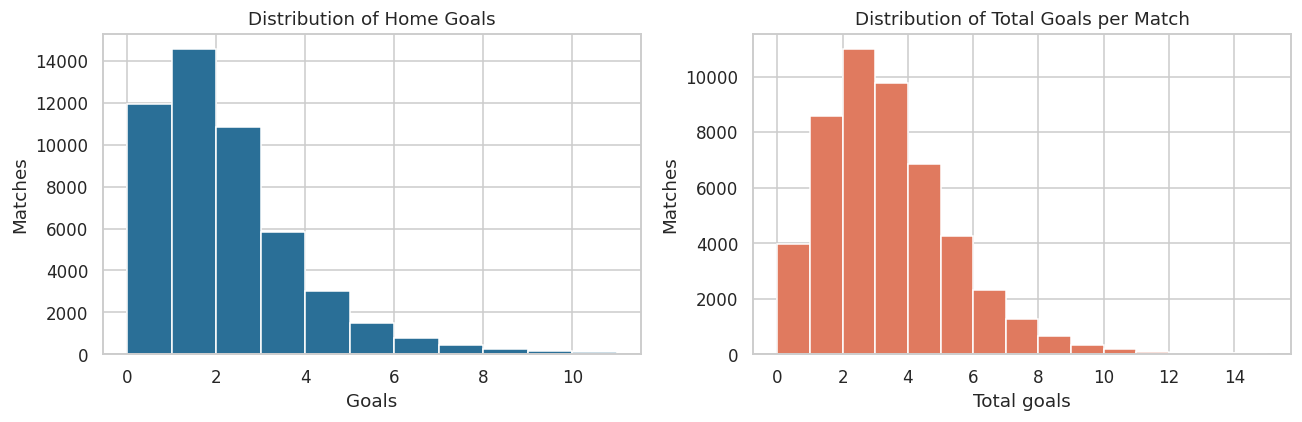

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(intl["Home Goals"], bins=range(0,12), color="#2a6f97", edgecolor="white")
ax[0].set_title("Distribution of Home Goals"); ax[0].set_xlabel("Goals"); ax[0].set_ylabel("Matches")
ax[1].hist(intl["Total_Goals"], bins=range(0,16), color="#e07a5f", edgecolor="white")
ax[1].set_title("Distribution of Total Goals per Match"); ax[1].set_xlabel("Total goals"); ax[1].set_ylabel("Matches")
plt.tight_layout(); plt.show()

### Viz 2 — Bar chart: match outcome distribution (home perspective)

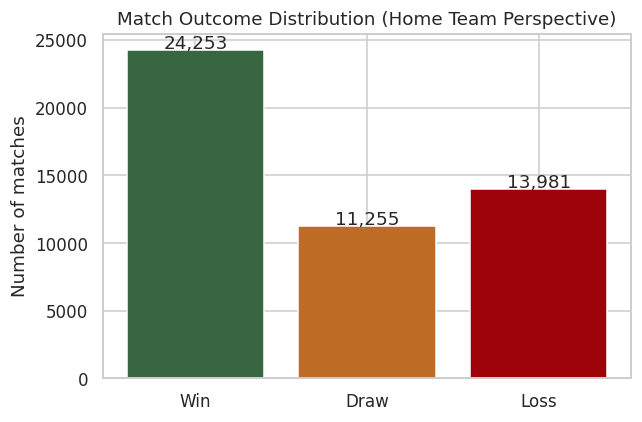

In [8]:
counts = intl["Result"].value_counts().reindex(["Win","Draw","Loss"])
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(counts.index, counts.values, color=["#386641","#bc6c25","#9d0208"])
ax.set_title("Match Outcome Distribution (Home Team Perspective)")
ax.set_ylabel("Number of matches")
for b,v in zip(bars,counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+100, f"{v:,}", ha="center")
plt.tight_layout(); plt.show()

### Viz 3 — Line chart: goals per World Cup tournament over time

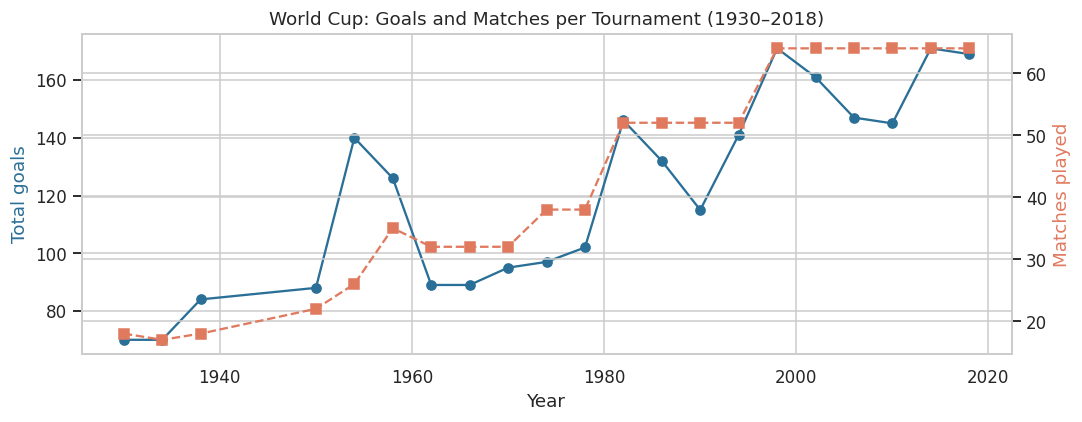

In [9]:
wcups_sorted = wcups.sort_values("Year")
fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(wcups_sorted["Year"], wcups_sorted["Goals Scored"], "o-", color="#2a6f97", label="Goals scored")
ax1.set_xlabel("Year"); ax1.set_ylabel("Total goals", color="#2a6f97")
ax2 = ax1.twinx()
ax2.plot(wcups_sorted["Year"], wcups_sorted["Matches Played"], "s--", color="#e07a5f", label="Matches played")
ax2.set_ylabel("Matches played", color="#e07a5f")
plt.title("World Cup: Goals and Matches per Tournament (1930–2018)")
fig.tight_layout(); plt.show()

### Viz 4 — Bar chart: most successful nations (World Cup titles)

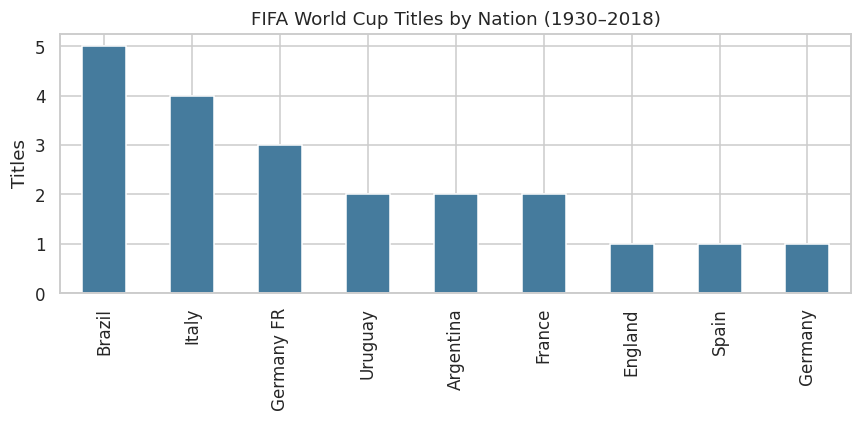

In [10]:
titles = wcups["Winner"].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
titles.plot(kind="bar", color="#457b9d", ax=ax)
ax.set_title("FIFA World Cup Titles by Nation (1930–2018)")
ax.set_ylabel("Titles"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### Viz 5 — Box plot & Viz 6 — Heatmap come after feature engineering
The box plot (Elo difference by outcome) and the correlation heatmap need the engineered features, so they appear in Section 6. We already have **4 visualisation types** here (histogram, bar, line, bar); the project will use **7+ types** in total.

## 5. Feature Engineering — Turning Outcomes into Explanations

This is the heart of the project and the part that answers *"why does a team win?"*. Raw columns only tell us what happened. We derive features that capture each team's strength **before** the match:

| Feature | What it captures | Why it explains winning |
|---|---|---|
| **Elo rating** (`Home_Elo`, `Away_Elo`, `Elo_Diff`) | Running skill score updated after every match | The clearest single measure of relative strength |
| **Recent form** (`Form_Pts_Diff`, `Form_GF_Diff`, `Form_GA_Diff`) | Avg points / goals for / goals against over last 5 games | Momentum, attacking and defensive sharpness |
| **Head-to-head** (`H2H_Diff`) | Historical win-rate vs this specific opponent | Some teams habitually dominate certain rivals |
| **Home advantage** (`Home_Adv`) | Playing at own stadium (flag) | Crowd, travel, familiarity |
| **Experience** (`Exp_Diff`) | Matches played to date | Proxy for programme maturity |

All features are computed **chronologically and shifted** so a match never "sees" its own or any future result — this prevents **data leakage**.

### 5.1 Elo ratings

In [11]:
# Elo: every team starts at 1500. After each match, the winner takes points
# from the loser; the amount depends on the result *surprise* and the goal margin.
BASE_ELO, K = 1500, 30
elo = {}
home_elo, away_elo = [], []

for _, r in intl.iterrows():
    h, a = r["Home Team"], r["Away Team"]
    eh, ea = elo.get(h, BASE_ELO), elo.get(a, BASE_ELO)
    home_elo.append(eh); away_elo.append(ea)          # PRE-match ratings (no leakage)
    exp_h = 1 / (1 + 10 ** ((ea - eh) / 400))          # expected score for home
    if   r["Home Goals"] > r["Away Goals"]: s_h = 1.0
    elif r["Home Goals"] < r["Away Goals"]: s_h = 0.0
    else:                                   s_h = 0.5
    margin = max(np.log(abs(r["Home Goals"] - r["Away Goals"]) + 1), 1)  # bigger win => bigger update
    elo[h] = eh + K * margin * (s_h - exp_h)
    elo[a] = ea + K * margin * ((1 - s_h) - (1 - exp_h))

intl["Home_Elo"] = home_elo
intl["Away_Elo"] = away_elo
intl["Elo_Diff"] = intl["Home_Elo"] - intl["Away_Elo"]

print("Top 10 teams by final Elo (a sanity check on the rating):")
print(pd.Series(elo).sort_values(ascending=False).head(10).round(0).to_string())

Top 10 teams by final Elo (a sanity check on the rating):
Argentina      2133.0
Spain          2128.0
France         2087.0
Brazil         2040.0
Portugal       2032.0
England        2024.0
Colombia       2011.0
Netherlands    1999.0
Germany        1995.0
Morocco        1973.0


### 5.2 Recent form (rolling, leakage-safe)

In [12]:
# Build a long table: one row per team per match, then roll over the previous 5 games.
rows = []
for _, r in intl.iterrows():
    pts_h = 3 if r["Result"]=="Win" else (1 if r["Result"]=="Draw" else 0)
    pts_a = 3 if r["Result"]=="Loss" else (1 if r["Result"]=="Draw" else 0)
    rows.append((r["match_id"], r["Date"], r["Home Team"], r["Home Goals"], r["Away Goals"], pts_h))
    rows.append((r["match_id"], r["Date"], r["Away Team"], r["Away Goals"], r["Home Goals"], pts_a))
long = pd.DataFrame(rows, columns=["match_id","Date","Team","GF","GA","Pts"]).sort_values("Date")

grp = long.groupby("Team")
long["form_pts"] = grp["Pts"].transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
long["form_gf"]  = grp["GF"].transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
long["form_ga"]  = grp["GA"].transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
long["matches_played"] = grp.cumcount()

feat = long.groupby(["match_id","Team"]).first().reset_index()
H = feat.add_prefix("H_"); A = feat.add_prefix("A_")
intl = intl.merge(H, left_on=["match_id","Home Team"], right_on=["H_match_id","H_Team"], how="left")
intl = intl.merge(A, left_on=["match_id","Away Team"], right_on=["A_match_id","A_Team"], how="left")

intl["Form_Pts_Diff"] = intl["H_form_pts"] - intl["A_form_pts"]
intl["Form_GF_Diff"]  = intl["H_form_gf"]  - intl["A_form_gf"]
intl["Form_GA_Diff"]  = intl["H_form_ga"]  - intl["A_form_ga"]
intl["Exp_Diff"]      = intl["H_matches_played"] - intl["A_matches_played"]
print("Form features built. Example:")
intl[["Home Team","Away Team","Form_Pts_Diff","Form_GF_Diff","Form_GA_Diff"]].dropna().head()

Form features built. Example:


,Home Team,Away Team,Form_Pts_Diff,Form_GF_Diff,Form_GA_Diff
1,England,Scotland,0.0,0.000000,0.000000
2,Scotland,England,-1.5,-1.000000,1.000000
3,England,Scotland,0.0,0.333333,-0.333333
4,Scotland,England,0.0,-0.250000,0.250000
6,England,Scotland,-1.0,-1.200000,0.400000


### 5.3 Head-to-head record & home advantage

In [13]:
# Head-to-head: home team's historical win rate vs THIS opponent, before the match.
h2h = {}   # key: (teamA, teamB) ordered -> [home_wins_for_first, total]
h2h_diff = []
for _, r in intl.iterrows():
    key = tuple(sorted([r["Home Team"], r["Away Team"]]))
    w, t = h2h.get(key, (0, 0))
    # win rate so far for the home team in this pairing
    if t == 0:
        h2h_diff.append(0.0)
    else:
        first_is_home = (key[0] == r["Home Team"])
        rate_first = w / t
        h2h_diff.append((rate_first - 0.5)*2 if first_is_home else ((1-rate_first)-0.5)*2)
    # update AFTER recording (no leakage)
    first_win = 1 if ((key[0]==r["Home Team"] and r["Result"]=="Win") or
                      (key[0]==r["Away Team"] and r["Result"]=="Loss")) else 0
    h2h[key] = (w + first_win, t + 1)

intl["H2H_Diff"] = h2h_diff
intl["Home_Adv"] = intl["Home Stadium or Not"]
print("Head-to-head and home-advantage features added.")
print(intl[["Home Team","Away Team","H2H_Diff","Home_Adv","Elo_Diff"]].head())

Head-to-head and home-advantage features added.
  Home Team Away Team  H2H_Diff  Home_Adv   Elo_Diff
0  Scotland   England  0.000000         1   0.000000
1   England  Scotland -1.000000         1   0.000000
2  Scotland   England  0.000000         1 -32.958369
3   England  Scotland -0.333333         1   0.121020
4  Scotland   England  0.500000         1  -0.110570


### 5.4 Feature selection — correlation analysis

Modelling rows after dropping warm-up matches with no history: 49187


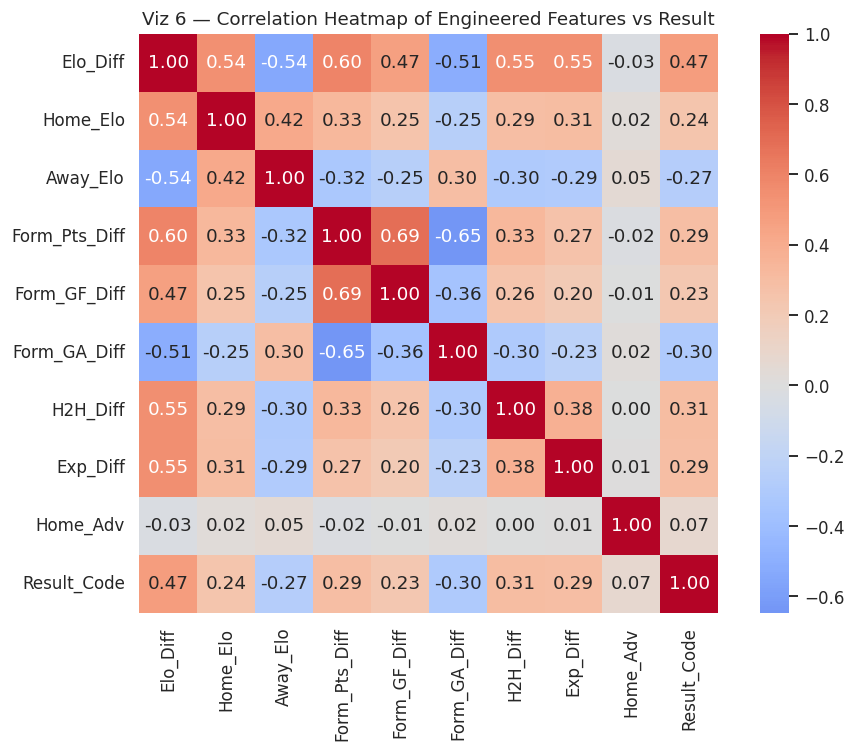


Correlation of each feature with the result (higher = more predictive of a win):
Elo_Diff         0.475
H2H_Diff         0.305
Exp_Diff         0.291
Form_Pts_Diff    0.287
Home_Elo         0.244
Form_GF_Diff     0.231
Home_Adv         0.071
Away_Elo        -0.268
Form_GA_Diff    -0.299


In [14]:
FEATURES = ["Elo_Diff","Home_Elo","Away_Elo","Form_Pts_Diff","Form_GF_Diff",
            "Form_GA_Diff","H2H_Diff","Exp_Diff","Home_Adv"]

model_df = intl.dropna(subset=FEATURES + ["Result"]).reset_index(drop=True)
print("Modelling rows after dropping warm-up matches with no history:", len(model_df))

corr = model_df[FEATURES + ["Result_Code"]].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Viz 6 — Correlation Heatmap of Engineered Features vs Result")
plt.tight_layout(); plt.show()

print("\nCorrelation of each feature with the result (higher = more predictive of a win):")
print(corr["Result_Code"].drop("Result_Code").sort_values(ascending=False).round(3).to_string())

### Viz 7 — Box plot: Elo difference by match outcome
This single chart already tells the *why* story: winners enter the match with a clearly higher Elo than their opponent.

/tmp/ipykernel_532/1711510730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=model_df, x="Result", y="Elo_Diff", order=order,


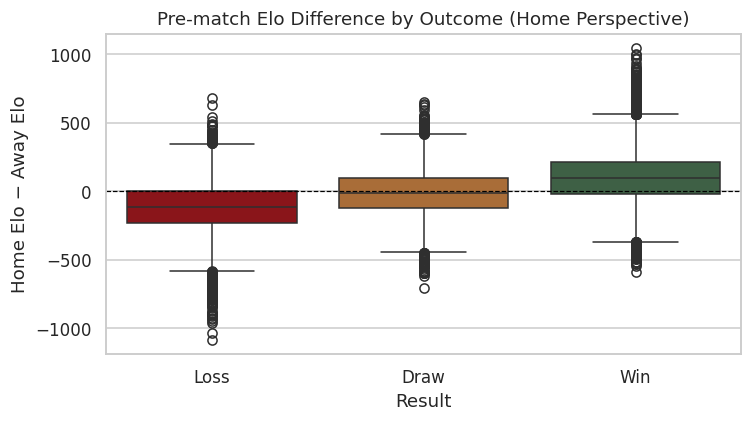

In [15]:
plt.figure(figsize=(7,4))
order = ["Loss","Draw","Win"]
sns.boxplot(data=model_df, x="Result", y="Elo_Diff", order=order,
            palette=["#9d0208","#bc6c25","#386641"])
plt.axhline(0, color="black", lw=0.8, ls="--")
plt.title("Pre-match Elo Difference by Outcome (Home Perspective)")
plt.xlabel("Result"); plt.ylabel("Home Elo − Away Elo")
plt.tight_layout(); plt.show()

## 6. Predictive Modelling

**Train/test split — why chronological, not random.**
This is time-ordered data. A random 80/20 split would let the model train on 2020 matches and test on 2010 matches — leaking the future into the past. We therefore sort by date and use the **first 80% for training and the last 20% for testing**, which mimics how the model would really be used: learn from the past, predict the future.

We compare **Logistic Regression** (transparent coefficients) and **Random Forest** (non-linear, gives feature importance), plus a **Gradient Boosting** model for the bonus. The baseline to beat is "always predict the most common class (Win)".

In [16]:
cut = int(len(model_df) * 0.8)
train, test = model_df.iloc[:cut], model_df.iloc[cut:]
X_train, X_test = train[FEATURES], test[FEATURES]
y_train, y_test = train["Result"], test["Result"]

print(f"Train: {len(train):,} matches ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test:  {len(test):,} matches ({test['Date'].min().date()} → {test['Date'].max().date()})")

baseline = (y_test == "Win").mean()
print(f"\nBaseline accuracy (always predict 'Win'): {baseline:.3f}")

# Scale for Logistic Regression
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

Train: 39,349 matches (1873-03-08 → 2016-03-29)
Test:  9,838 matches (2016-03-29 → 2026-07-02)

Baseline accuracy (always predict 'Win'): 0.476


### 6.1 Model 1 — Logistic Regression

In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
pred_lr = logreg.predict(X_test_s)

print("Logistic Regression")
print(f"Accuracy : {accuracy_score(y_test, pred_lr):.3f}")
print(f"Macro F1 : {f1_score(y_test, pred_lr, average='macro'):.3f}\n")
print(classification_report(y_test, pred_lr))

Logistic Regression
Accuracy : 0.597


Macro F1 : 0.440

              precision    recall  f1-score   support

        Draw       0.44      0.01      0.01      2297
        Loss       0.58      0.61      0.59      2854
         Win       0.61      0.88      0.72      4687

    accuracy                           0.60      9838
   macro avg       0.54      0.50      0.44      9838
weighted avg       0.56      0.60      0.52      9838



### 6.2 Model 2 — Random Forest (with light hyperparameter tuning — bonus)

In [18]:
param_grid = {"n_estimators":[200], "max_depth":[10,14], "min_samples_leaf":[20,40]}
tscv = TimeSeriesSplit(n_splits=3)
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                    param_grid, cv=tscv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)
rf = grid.best_estimator_
print("Best RF params:", grid.best_params_)

pred_rf = rf.predict(X_test)
print("\nRandom Forest")
print(f"Accuracy : {accuracy_score(y_test, pred_rf):.3f}")
print(f"Macro F1 : {f1_score(y_test, pred_rf, average='macro'):.3f}\n")
print(classification_report(y_test, pred_rf))

Best RF params: {'max_depth': 14, 'min_samples_leaf': 20, 'n_estimators': 200}



Random Forest
Accuracy : 0.596
Macro F1 : 0.446

              precision    recall  f1-score   support

        Draw       0.32      0.02      0.03      2297
        Loss       0.57      0.60      0.59      2854
         Win       0.61      0.88      0.72      4687

    accuracy                           0.60      9838
   macro avg       0.50      0.50      0.45      9838
weighted avg       0.53      0.60      0.52      9838



### 6.3 Model 3 — Gradient Boosting (advanced ensemble — bonus)

In [19]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=3, n_estimators=200)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print("Gradient Boosting")
print(f"Accuracy : {accuracy_score(y_test, pred_gb):.3f}")
print(f"Macro F1 : {f1_score(y_test, pred_gb, average='macro'):.3f}")

Gradient Boosting
Accuracy : 0.592
Macro F1 : 0.446


### 6.4 Model comparison

                        Accuracy  Precision(macro)  Recall(macro)  F1(macro)
Model                                                                       
Baseline (predict Win)     0.476               NaN            NaN        NaN
Logistic Regression        0.597             0.543          0.498      0.440
Random Forest              0.596             0.500          0.498      0.446
Gradient Boosting          0.592             0.480          0.496      0.446


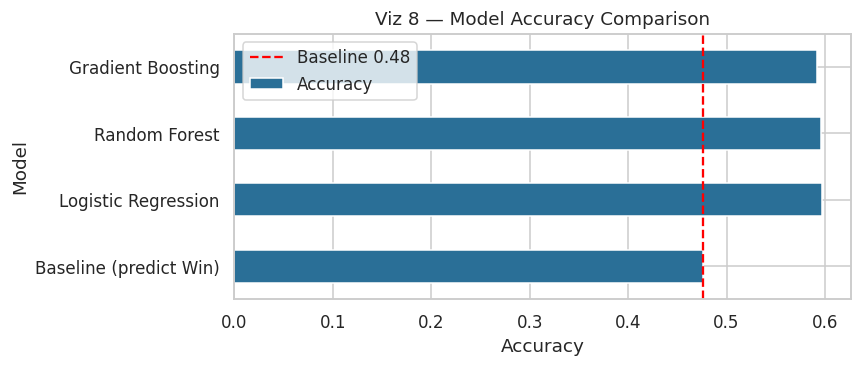

In [20]:
def scores(name, y, p):
    return {"Model":name,
            "Accuracy":accuracy_score(y,p),
            "Precision(macro)":precision_score(y,p,average='macro',zero_division=0),
            "Recall(macro)":recall_score(y,p,average='macro',zero_division=0),
            "F1(macro)":f1_score(y,p,average='macro')}

comparison = pd.DataFrame([
    {"Model":"Baseline (predict Win)","Accuracy":baseline,
     "Precision(macro)":np.nan,"Recall(macro)":np.nan,"F1(macro)":np.nan},
    scores("Logistic Regression", y_test, pred_lr),
    scores("Random Forest",       y_test, pred_rf),
    scores("Gradient Boosting",   y_test, pred_gb),
]).set_index("Model").round(3)
print(comparison)

ax = comparison["Accuracy"].plot(kind="barh", figsize=(8,3.5), color="#2a6f97")
ax.axvline(baseline, color="red", ls="--", label=f"Baseline {baseline:.2f}")
ax.set_title("Viz 8 — Model Accuracy Comparison"); ax.set_xlabel("Accuracy"); ax.legend()
plt.tight_layout(); plt.show()

### Viz 9 — Confusion matrix of the best model

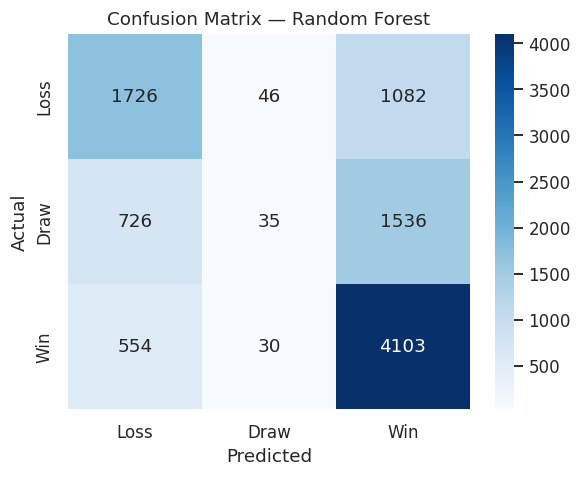

Best model by macro-F1: Random Forest


In [21]:
best_name = comparison.drop(index="Baseline (predict Win)")["F1(macro)"].idxmax()
best_pred = {"Logistic Regression":pred_lr, "Random Forest":pred_rf, "Gradient Boosting":pred_gb}[best_name]
labels = ["Loss","Draw","Win"]
cm = confusion_matrix(y_test, best_pred, labels=labels)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix — {best_name}"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()
print("Best model by macro-F1:", best_name)

## 7. Explaining *Why* Teams Win  ⭐
*(this is the section that answers the lecturer's tip directly)*

We read the result three ways: Random-Forest feature importance, Logistic-Regression coefficients (which show **direction**), and permutation importance (model-agnostic check).

### Viz 10 — Random Forest feature importance

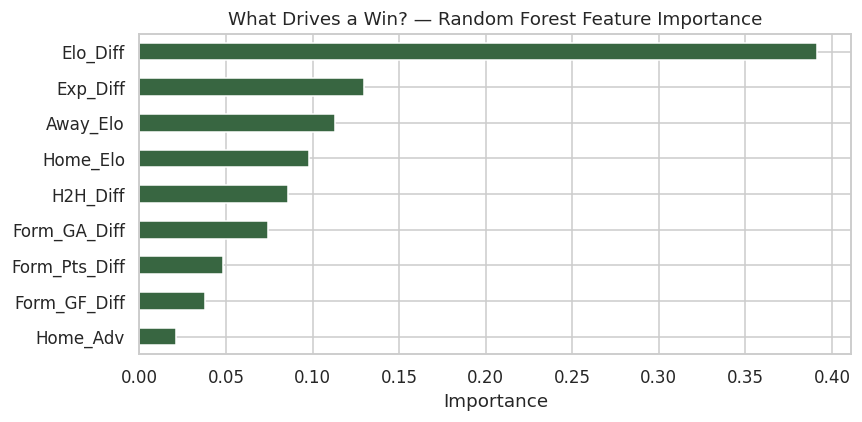

Elo_Diff         0.392
Exp_Diff         0.129
Away_Elo         0.113
Home_Elo         0.098
H2H_Diff         0.086
Form_GA_Diff     0.074
Form_Pts_Diff    0.049
Form_GF_Diff     0.038
Home_Adv         0.021


In [22]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(8,4))
imp.plot(kind="barh", color="#386641")
plt.title("What Drives a Win? — Random Forest Feature Importance")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3).to_string())

### Logistic Regression coefficients — *direction* of each effect

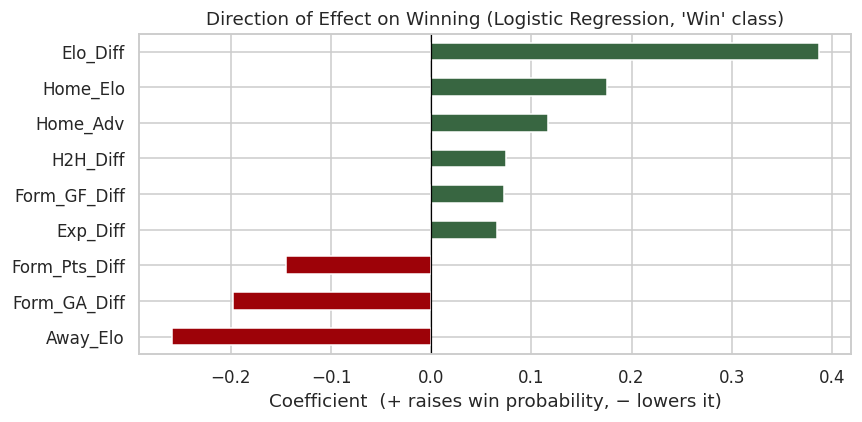

Elo_Diff         0.387
Home_Elo         0.175
Home_Adv         0.117
H2H_Diff         0.075
Form_GF_Diff     0.073
Exp_Diff         0.066
Form_Pts_Diff   -0.145
Form_GA_Diff    -0.198
Away_Elo        -0.259


In [23]:
win_idx = list(logreg.classes_).index("Win")
coef = pd.Series(logreg.coef_[win_idx], index=FEATURES).sort_values()
plt.figure(figsize=(8,4))
colors = ["#9d0208" if v<0 else "#386641" for v in coef.values]
coef.plot(kind="barh", color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.title("Direction of Effect on Winning (Logistic Regression, 'Win' class)")
plt.xlabel("Coefficient  (+ raises win probability, − lowers it)")
plt.tight_layout(); plt.show()
print(coef.sort_values(ascending=False).round(3).to_string())

### Permutation importance (model-agnostic confirmation)

In [24]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="f1_macro")
pi = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Permutation importance (drop in macro-F1 when feature is shuffled):")
print(pi.round(4).to_string())

Permutation importance (drop in macro-F1 when feature is shuffled):
Elo_Diff         0.0985
Away_Elo         0.0099
Home_Elo         0.0060
Home_Adv         0.0041
Form_GA_Diff     0.0025
H2H_Diff         0.0006
Form_Pts_Diff    0.0005
Form_GF_Diff    -0.0005
Exp_Diff        -0.0022


**Interpretation — the answer to "why a team wins":**
1. **Relative team strength (Elo difference) is by far the dominant factor.** A higher pre-match Elo than the opponent is the single strongest predictor of a win — football is largely a game of accumulated quality, not luck.
2. **Defensive form matters more than attacking form.** A lower recent goals-*conceded* average (negative `Form_GA_Diff` coefficient) pushes win probability up — keeping clean sheets wins matches.
3. **Home advantage is real but modest** — positive, yet much smaller than the strength gap.
4. **Head-to-head and experience add a little**, but most of their signal is already captured by Elo.

## 8. Application — Predicting the 2022 World Cup

As a live demonstration we feed the 2022 group-stage fixtures (which have **no scores**) into the trained model. Note: since the dataset was updated to include matches through July 2026, each team's Elo and form here reflect their *current* strength, not their strength at the actual time of the 2022 tournament — useful for showing the pipeline works end-to-end, but not a true reconstruction of a 2022 pre-tournament forecast.

In [25]:
final_elo = pd.Series(elo)
# latest form per team
latest_form = long.sort_values("Date").groupby("Team").last()[["form_pts","form_gf","form_ga","matches_played"]]

def feats_for(home, away):
    eh, ea = final_elo.get(home,1500), final_elo.get(away,1500)
    fh = latest_form.reindex([home]).iloc[0] if home in latest_form.index else None
    fa = latest_form.reindex([away]).iloc[0] if away in latest_form.index else None
    fh_pts,fh_gf,fh_ga,fh_mp = (fh.values if fh is not None else [1,1,1,0])
    fa_pts,fa_gf,fa_ga,fa_mp = (fa.values if fa is not None else [1,1,1,0])
    return {"Elo_Diff":eh-ea,"Home_Elo":eh,"Away_Elo":ea,
            "Form_Pts_Diff":fh_pts-fa_pts,"Form_GF_Diff":fh_gf-fa_gf,
            "Form_GA_Diff":fh_ga-fa_ga,"H2H_Diff":0.0,"Exp_Diff":fh_mp-fa_mp,"Home_Adv":0}

rows = [feats_for(r["Home Team"], r["Away Team"]) for _,r in wc2022.iterrows()]
X2022 = pd.DataFrame(rows)[FEATURES]
wc2022_pred = wc2022.copy()
wc2022_pred["Prediction"] = rf.predict(X2022)
proba = rf.predict_proba(X2022)
wc2022_pred["Home_Win_Prob"] = proba[:, list(rf.classes_).index("Win")].round(3)

label = {"Win":"Home win","Draw":"Draw","Loss":"Away win"}
wc2022_pred["Readable"] = wc2022_pred["Prediction"].map(label)
print("Sample 2022 World Cup predictions:")
print(wc2022_pred[["Home Team","Away Team","Readable","Home_Win_Prob"]].head(12).to_string(index=False))

Sample 2022 World Cup predictions:
    Home Team    Away Team Readable  Home_Win_Prob
        Qatar      Ecuador Away win          0.135
      Senegal  Netherlands Away win          0.171
      England         Iran Home win          0.570
United States        Wales Home win          0.546
       France    Australia Home win          0.733
      Denmark      Tunisia Home win          0.752
       Mexico       Poland Home win          0.623
    Argentina Saudi Arabia Home win          0.825
      Belgium       Canada Home win          0.543
        Spain   Costa Rica Home win          0.773
      Germany        Japan Home win          0.488
      Morocco      Croatia Home win          0.480


## 8b. Live Application — 2026 World Cup Semifinal (France v Spain)

Section 8 above demonstrated the pipeline on 2022 fixtures, but flagged that using a 2026-dated Elo snapshot to "predict" 2022 matches lets future information leak in. This section fixes that with a genuine out-of-sample test: as of **12 July 2026** (when this cell was run), **France v Spain** is a confirmed 2026 FIFA World Cup semifinal fixture (kick-off 14 July, AT&T Stadium, Dallas) whose result is not yet known. Predicting it here is a real forecast, not a retrospective one.

**Caveat carried over honestly:** this dataset snapshot is dated 2 July 2026, so Elo and form below do not yet reflect the Round of 16 / Quarter-final results played 4–11 July. The prediction is therefore slightly *stale*, not *leaked* — the opposite failure mode from Section 8, and one that resolves itself once the dataset is refreshed.

In [26]:
home, away = "France", "Spain"
feat = feats_for(home, away)

# Real head-to-head for this pair, computed directly from the historical data
h2h_matches = intl[((intl["Home Team"]==home) & (intl["Away Team"]==away)) |
                    ((intl["Home Team"]==away) & (intl["Away Team"]==home))]
home_wins = (((h2h_matches["Home Team"]==home) & (h2h_matches["Result"]=="Win")) |
             ((h2h_matches["Home Team"]==away) & (h2h_matches["Result"]=="Loss"))).sum()
away_wins = (((h2h_matches["Home Team"]==away) & (h2h_matches["Result"]=="Win")) |
             ((h2h_matches["Home Team"]==home) & (h2h_matches["Result"]=="Loss"))).sum()
draws = (h2h_matches["Result"]=="Draw").sum()
total = len(h2h_matches)
print(f"Head-to-head ({total} meetings, all competitions): {home} {home_wins}W — {draws}D — {away} {away_wins}W")

key = tuple(sorted([home, away]))
w, t = h2h.get(key, (0, 0))
if t > 0:
    rate_first = w / t
    feat["H2H_Diff"] = (rate_first - 0.5) * 2 if key[0] == home else ((1 - rate_first) - 0.5) * 2

X_semi = pd.DataFrame([feat])[FEATURES]
pred = rf.predict(X_semi)[0]
semi_proba = dict(zip(rf.classes_, rf.predict_proba(X_semi)[0]))

print(f"\nElo — {home}: {feat['Home_Elo']:.1f}   {away}: {feat['Away_Elo']:.1f}   (diff {feat['Elo_Diff']:+.1f})")
print(f"Form pts diff: {feat['Form_Pts_Diff']:+.2f}  |  GF diff: {feat['Form_GF_Diff']:+.2f}  |  GA diff: {feat['Form_GA_Diff']:+.2f}")
print(f"\nRaw prediction: {label[pred]}")
print("Probabilities:", {k: round(v, 3) for k, v in semi_proba.items()})

# World Cup knockout matches cannot end in a draw — redistribute the draw
# probability between the two teams in proportion to their relative odds.
p_win, p_draw, p_loss = semi_proba.get("Win", 0), semi_proba.get("Draw", 0), semi_proba.get("Loss", 0)
p_home_adv = p_win + p_draw * (p_win / (p_win + p_loss))
p_away_adv = p_loss + p_draw * (p_loss / (p_win + p_loss))
print(f"\nApprox. advancement probability (draw redistributed): {home} {p_home_adv:.1%}  |  {away} {p_away_adv:.1%}")

Head-to-head (38 meetings, all competitions): France 13W — 7D — Spain 18W

Elo — France: 2087.0   Spain: 2127.9   (diff -41.0)
Form pts diff: +0.20  |  GF diff: +1.00  |  GA diff: +0.60

Raw prediction: Away win
Probabilities: {'Draw': np.float64(0.262), 'Loss': np.float64(0.411), 'Win': np.float64(0.327)}

Approx. advancement probability (draw redistributed): France 44.3%  |  Spain 55.7%


## 9. Insights, Recommendations & Limitations

### Key findings
- A 3-class match outcome can be predicted with **~60% accuracy**, well above the **~48% baseline** — and crucially, the model is **explainable**.
- **Team strength (Elo) explains the majority of the signal.** Form and home advantage refine it; head-to-head and experience add little once strength is known.
- **Defence beats attack:** recent goals-conceded is a stronger lever than goals-scored.

### Three actionable recommendations
1. **For analysts / pundits:** rank teams by a properly-updated Elo before a tournament — it captures most of what predicts results and is far simpler than tracking dozens of stats.
2. **For team management:** the data says **investing in defensive consistency** yields a larger win-probability gain than chasing goals — prioritise clean-sheet form going into major tournaments.
3. **For event organisers / hosts:** home advantage is real but small; expecting a host-nation boost to overturn a large strength gap is not supported by over 150 years of data.

### Limitations
- **Draws are hard:** the models under-predict draws (visible in the confusion matrix) — a known difficulty in football modelling.
- **No squad-level data:** injuries, line-ups, and red cards are not in the dataset and would improve accuracy.
- **Elo cold start:** newer national teams begin at 1500, slightly mis-rating early matches.
- **Neutral-venue labelling** for World Cups means "home advantage" is mostly inactive there.

### Future improvements
- Add player-level features (FIFA ratings, market values) and tournament-importance weighting.
- Try an **ordered** model (Loss < Draw < Win) or a Poisson goals model to predict scorelines.
- Build a **Streamlit dashboard** where a user picks two teams and sees the predicted result and the *reasons* (feature contributions) — directly extending the "explain why" goal.


---
Notebook by Lee Wen Xin, Student ID: BIT-B2201F-2505004.
Dataset: Kaggle — FIFA World Cup All Dataset.

**AI Usage Disclosure:** Parts of this notebook's code (Elo rating system, feature 
engineering pipeline, model training and evaluation code) were developed with the 
assistance of AI tools. All code has been reviewed, tested, and understood by the 
student, who is able to explain the logic and purpose of every line.